In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3

In [2]:
conn = sqlite3.connect('sales.db')

In [3]:
cur = conn.cursor()

In [4]:
cur.execute(''' CREATE TABLE IF NOT EXISTS products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT,
    category TEXT,
    price INTEGER,
    quantity INTEGER
)
''')

In [5]:
cur.execute("INSERT INTO products (product_name, category, price) VALUES (?,?,?)", ('Phone', 'Tech', 400))

In [6]:
cur.execute("INSERT INTO products (product_name, category, price) VALUES (?,?,?)", ('Chair', 'Furniture', 40))

In [7]:
cur.execute("INSERT INTO products (product_name, category, price) VALUES (?,?,?)", ('Laptop', 'Tech', 800))

In [8]:
cur.execute("INSERT INTO products (product_name, category, price) VALUES (?,?,?)", ('Paper', 'Office', 200))

In [9]:
cur.execute("INSERT INTO products (product_name, category, price) VALUES (?,?,?)", ('Pen', 'Office', 10))

In [10]:
conn.commit()

In [11]:
cur.execute('SELECT * FROM products')
rows = cur.fetchall()
for row in rows:
  print(row)

(1, 'Phone', 'Tech', 400)
(2, 'Chair', 'Furniture', 40)
(3, 'Laptop', 'Tech', 800)
(5, 'Pen', 'Office', 200)
(6, 'Laptop', 'Tech', 800)
(7, 'Phone', 'Tech', 400)
(8, 'Chair', 'Furniture', 40)
(9, 'Laptop', 'Tech', 800)
(10, 'Paper', 'Office', 200)
(11, 'Pen', 'Office', 10)


In [12]:
cur.execute("UPDATE products SET price = 200 WHERE product_name='Pen'")

cur.execute('Select * from products')
rows = cur.fetchall()
for row in rows:
  print(row)

(1, 'Phone', 'Tech', 400)
(2, 'Chair', 'Furniture', 40)
(3, 'Laptop', 'Tech', 800)
(5, 'Pen', 'Office', 200)
(6, 'Laptop', 'Tech', 800)
(7, 'Phone', 'Tech', 400)
(8, 'Chair', 'Furniture', 40)
(9, 'Laptop', 'Tech', 800)
(10, 'Paper', 'Office', 200)
(11, 'Pen', 'Office', 200)


In [13]:
cur.execute("delete from products where product_name='Paper'")

cur.execute('select * from products')
rows = cur.fetchall()
for row in rows:
  print(row)

(1, 'Phone', 'Tech', 400)
(2, 'Chair', 'Furniture', 40)
(3, 'Laptop', 'Tech', 800)
(5, 'Pen', 'Office', 200)
(6, 'Laptop', 'Tech', 800)
(7, 'Phone', 'Tech', 400)
(8, 'Chair', 'Furniture', 40)
(9, 'Laptop', 'Tech', 800)
(11, 'Pen', 'Office', 200)


In [14]:
data = pd.read_sql_query('select * from products', conn)

<ipython-input-15-3d53d64201c6>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=data, palette = 'viridis')


<Axes: xlabel='category', ylabel='count'>

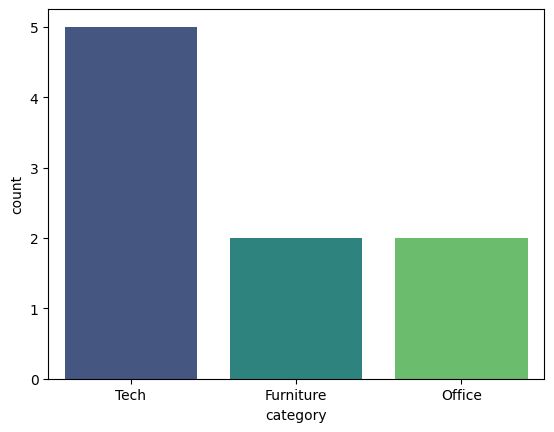

In [15]:
sns.countplot(x='category', data=data, palette = 'viridis')

In [16]:
cur.execute("insert into products (product_name, category, price) VALUES (?,?,?)", ('Table', 'Furniture', 43))

In [17]:
cur.execute("insert into products (product_name, category, price) VALUES (?,?,?)", ('Car', 'Automotive', 600))

<Axes: ylabel='Frequency'>

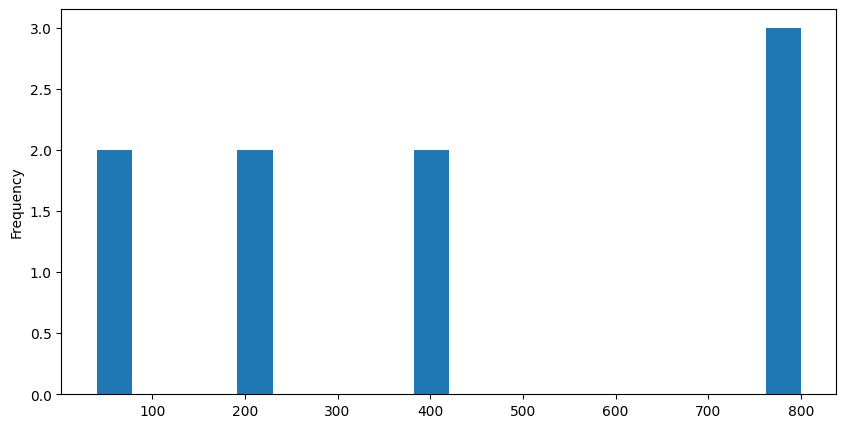

In [19]:
data['price'].plot.hist(bins=20, figsize=(10,5))

<ipython-input-21-e784e32055ac>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=data, palette = 'viridis')


<Axes: xlabel='count', ylabel='category'>

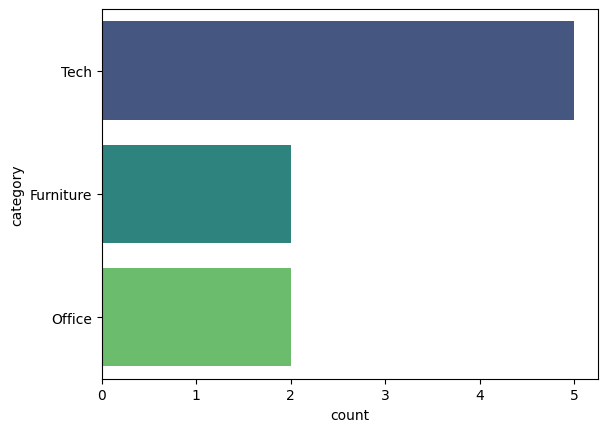

In [21]:
sns.countplot(y='category', data=data, palette = 'viridis')

In [25]:
data1 = data.drop('product_id', axis = 1)

<Axes: >

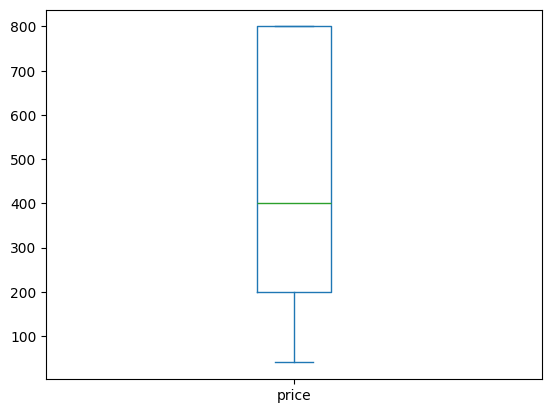

In [27]:
data1.plot(kind='box')